## Data Processing & Feature Engineering

In [1]:
# load data and inspect shape
import pandas as pd

df = pd.read_parquet("data/merged/final_merged_panel.parquet")
df.shape

(12715, 33)

#### Train-Test Split

In [2]:
# split train, validation, and test sets
from sklearn.model_selection import train_test_split

# 70/15/15 split for train/validation/test
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
train_df, val_df = train_test_split(train_df, test_size=0.25, random_state=42)

print(f"Train set shape: {train_df.shape}")
print(f"Validation set shape: {val_df.shape}")
print(f"Test set shape: {test_df.shape}")

Train set shape: (7629, 33)
Validation set shape: (2543, 33)
Test set shape: (2543, 33)


In [3]:
# check distribution of target variable
train_df["recession"].value_counts()

recession
0    7186
1     443
Name: count, dtype: int64

In [4]:
# separate features and target variable
X_train = train_df.drop("recession", axis=1)
y_train = train_df["recession"]

X_val = val_df.drop("recession", axis=1)
y_val = val_df["recession"]

X_test = test_df.drop("recession", axis=1)
y_test = test_df["recession"]

#### Interaction Terms
- Growth × Inflation (stagflation signal)
    - Recessions often occur when inflation is high while growth weakens
- Exports × Imports (trade balance pressure)
    - Trade imbalances can signal vulnerability to downturns
- Government Consumption × GDP Growth (policy cushioning)
    - Tests whether government spending moderates weak growth
- Current Account × GDP Growth (external imbalance + slowdown)
    - Countries with deficits during slow growth may face recession risk
- Inflation × Import Share (imported inflation)
    - High imports combined with inflation can reflect supply shocks

In [5]:
def add_interactions(df):
    df = df.copy()

    df["growth_inflation"] = df["wb_gdp_growth"] * df["wb_inflation_cpi"]
    df["exports_imports"] = df["wb_exports_pct_gdp"] * df["wb_imports_pct_gdp"]
    df["gov_growth"] = df["wb_gov_consumption_pct_gdp"] * df["wb_gdp_growth"]
    df["current_account_growth"] = (
        df["wb_current_account_pct_gdp"] * df["wb_gdp_growth"]
    )
    df["inflation_imports"] = df["wb_inflation_cpi"] * df["wb_imports_pct_gdp"]

    return df

In [6]:
X_train = add_interactions(X_train)
X_val = add_interactions(X_val)
X_test = add_interactions(X_test)

#### One Hot Encoding (OHE)

In [7]:
# check data types of columns
num_cols = X_train.select_dtypes(include=["number"]).columns
cat_cols = X_train.select_dtypes(include=["object", "category", "bool"]).columns

print("Numerical:", list(num_cols))
print("Categorical:", list(cat_cols))

Numerical: ['year', 'wb_current_account_pct_gdp', 'wb_exports_pct_gdp', 'wb_gdp_growth', 'wb_gov_consumption_pct_gdp', 'wb_imports_pct_gdp', 'wb_inflation_cpi', 'imf_inflation_imf', 'non_null_feature_count', 'feature_coverage_pct', 'wb_current_account_pct_gdp_lag1', 'wb_current_account_pct_gdp_lag2', 'wb_exports_pct_gdp_lag1', 'wb_exports_pct_gdp_lag2', 'wb_gdp_growth_lag1', 'wb_gdp_growth_lag2', 'wb_gov_consumption_pct_gdp_lag1', 'wb_gov_consumption_pct_gdp_lag2', 'wb_imports_pct_gdp_lag1', 'wb_imports_pct_gdp_lag2', 'wb_inflation_cpi_lag1', 'wb_inflation_cpi_lag2', 'imf_inflation_imf_lag1', 'imf_inflation_imf_lag2', 'wb_current_account_pct_gdp_chg1', 'wb_exports_pct_gdp_chg1', 'wb_gdp_growth_chg1', 'wb_gov_consumption_pct_gdp_chg1', 'wb_imports_pct_gdp_chg1', 'wb_inflation_cpi_chg1', 'imf_inflation_imf_chg1', 'growth_inflation', 'exports_imports', 'gov_growth', 'current_account_growth', 'inflation_imports']
Categorical: ['country']


In [8]:
# create separate DataFrames for numerical features
X_train_num = X_train[num_cols].reset_index(drop=True)
X_val_num = X_val[num_cols].reset_index(drop=True)
X_test_num = X_test[num_cols].reset_index(drop=True)

In [9]:
# one-hot encode categorical variable "country"
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

X_train_cat = encoder.fit_transform(X_train[cat_cols])
X_val_cat = encoder.transform(X_val[cat_cols])
X_test_cat = encoder.transform(X_test[cat_cols])

In [10]:
# convert encoded arrays back to DataFrames
ohe_cols = encoder.get_feature_names_out(cat_cols)

X_train_cat = pd.DataFrame(X_train_cat, columns=ohe_cols).reset_index(drop=True)
X_val_cat = pd.DataFrame(X_val_cat, columns=ohe_cols).reset_index(drop=True)
X_test_cat = pd.DataFrame(X_test_cat, columns=ohe_cols).reset_index(drop=True)

#### Corrleation Filtering

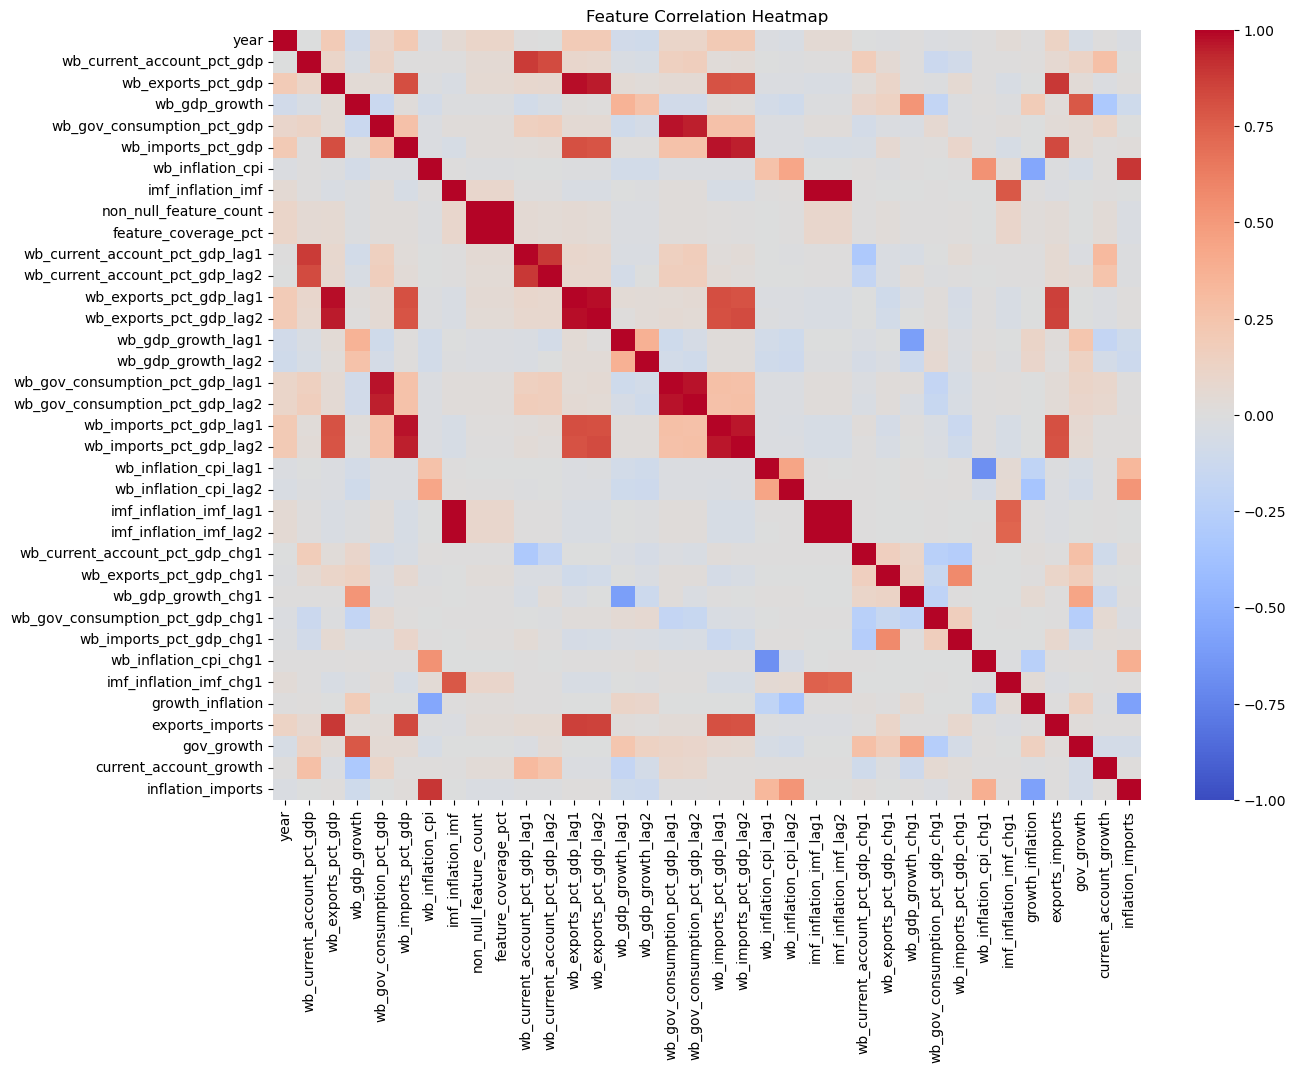

In [11]:
# visualize correlation matrix of numerical features
import seaborn as sns
import matplotlib.pyplot as plt

corr = X_train_num.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Feature Correlation Heatmap")
plt.show()

In [12]:
# identify highly correlated features (correlation > 0.9)
import numpy as np

corr_matrix = X_train_num.corr().abs()

# upper triangle of correlation matrix
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# columns to drop
to_drop = [col for col in upper.columns if any(upper[col] > 0.9)]

print("Columns to drop:", to_drop)

Columns to drop: ['feature_coverage_pct', 'wb_exports_pct_gdp_lag1', 'wb_exports_pct_gdp_lag2', 'wb_gov_consumption_pct_gdp_lag1', 'wb_gov_consumption_pct_gdp_lag2', 'wb_imports_pct_gdp_lag1', 'wb_imports_pct_gdp_lag2', 'imf_inflation_imf_lag1', 'imf_inflation_imf_lag2']


In [13]:
# drop highly correlated features from numerical data
X_train_processed = X_train_num.drop(columns=to_drop)
X_val_processed = X_val_num.drop(columns=to_drop)
X_test_processed = X_test_num.drop(columns=to_drop)

#### Standarization

In [18]:
# standardize numerical features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_processed),
    columns=X_train_processed.columns,
    index=X_train_processed.index,
)

X_val_scaled = pd.DataFrame(
    scaler.transform(X_val_processed),
    columns=X_val_processed.columns,
    index=X_val_processed.index,
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_processed),
    columns=X_test_processed.columns,
    index=X_test_processed.index,
)

In [20]:
# finalize feature set by concatenating numerical and ohe features
X_train_processed = pd.concat([X_train_scaled, X_train_cat], axis=1)
X_val_processed = pd.concat([X_val_scaled, X_val_cat], axis=1)
X_test_processed = pd.concat([X_test_scaled, X_test_cat], axis=1)

## Logistic Regression

In [ ]:
# perform grid search for logistic regression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

param_grid = {
    "C": [0.001, 0.01, 0.1, 1, 10],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear"],
    "class_weight": [None, "balanced"],
}

model = LogisticRegression(max_iter=2000)

grid = GridSearchCV(model, param_grid, cv=5, scoring="roc_auc", n_jobs=-1)

grid.fit(X_train_processed, y_train)

print(grid.best_params_)

{'C': 0.1, 'class_weight': 'balanced', 'penalty': 'l1', 'solver': 'liblinear'}


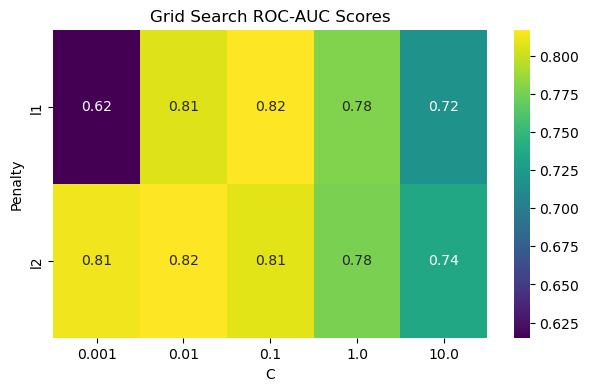

In [ ]:
# visualize grid search results
results = pd.DataFrame(grid.cv_results_)

pivot = results.pivot_table(
    values="mean_test_score", index="param_penalty", columns="param_C"
)

plt.figure(figsize=(7, 4))
sns.heatmap(pivot, annot=True, cmap="viridis")
plt.title("Grid Search ROC-AUC Scores")
plt.xlabel("C")
plt.ylabel("Penalty")
plt.show()

In [25]:
best_model = grid.best_estimator_

from sklearn.metrics import roc_auc_score

y_val_pred = best_model.predict_proba(X_val_processed)[:, 1]
roc_auc_score(y_val, y_val_pred)

0.8422019195275009